#   Data Analytics Project - การวิเคราะห์การต่อสัญญาการใช้บริการของลูกค้า

### Setup

In [48]:
%pip install pandas numpy seaborn matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data Collection

In [2]:
df = pd.read_csv('telco.csv', encoding='UTF-8')

In [3]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [5]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


### Data Cleaning

In [7]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

In [45]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv,churn_category,churn_reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   married                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   country                            7043 non-null   object 
 9   state                              7043 non-null   object 
 10  city                               7043 non-null   object 
 11  zip_code                           7043 non-null   int64

In [47]:
df.loc[df['tenure_in_months'].isin(['-'])]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv,churn_category,churn_reason


In [48]:
df['offer'].isnull().sum()

3877

In [49]:
df['offer'] = df.offer.fillna("No Offer")
df[pd.isnull(df.offer)]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv,churn_category,churn_reason


In [50]:
df['internet_type'].isnull().sum()

1526

In [51]:
df['internet_type'] = df['internet_type'].fillna("No Internet")
df[pd.isnull(df['internet_type'])]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv,churn_category,churn_reason


In [52]:
cols = ['country', 'state', 'latitude', 'longitude', 'quarter', 'churn_category', 'churn_reason']
df.drop(columns=cols, inplace=True)

In [53]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,...,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,...,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,...,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,...,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793


In [54]:
df.loc[df['customer_status'].isin(['Joined'])]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
477,4929-XIHVW,Male,79,No,Yes,Yes,No,0,Los Angeles,90034,...,181.65,0.0,10,66.20,257.85,5,Joined,No,69,4449
478,3413-BMNZE,Male,71,No,Yes,No,No,0,Los Angeles,90037,...,45.25,0.0,0,11.89,57.14,3,Joined,No,40,3144
486,2424-WVHPL,Male,79,No,Yes,No,No,0,Redondo Beach,90278,...,74.70,0.0,0,27.65,102.35,5,Joined,No,60,4182
508,0021-IKXGC,Female,72,No,Yes,No,No,0,San Marcos,92078,...,72.10,0.0,0,7.77,79.87,4,Joined,No,50,4432
514,0224-RLWWD,Female,73,No,Yes,No,No,0,Calexico,92231,...,89.30,0.0,0,47.82,137.12,3,Joined,No,44,3805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6968,9398-MMQTO,Male,41,No,No,No,No,0,Borrego Springs,92004,...,221.10,0.0,70,104.40,395.50,5,Joined,No,61,3956
6983,9039-ZVJDC,Male,49,No,No,No,No,0,Pauma Valley,92061,...,53.05,0.0,0,48.96,102.01,3,Joined,No,68,4905
7003,5351-QESIO,Male,64,No,No,No,Yes,2,San Diego,92122,...,24.20,0.0,0,0.00,24.20,5,Joined,No,80,4276
7025,1471-GIQKQ,Female,37,No,No,No,No,0,Niland,92257,...,49.95,0.0,0,44.98,94.93,3,Joined,No,32,5230


In [55]:
df = df[df['customer_status'] != 'Joined']
df.shape

(6589, 43)

In [56]:
df.loc[(df['phone_service'] == 'No') & (df['multiple_lines'] == 'Yes')]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv


In [57]:
df.loc[(df['avg_monthly_long_distance_charges']== 0)]

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.0,59.65,3,Churned,Yes,91,5433
7,3445-HXXGF,Male,66,No,Yes,Yes,No,0,Sierra Madre,91024,...,2651.20,40.95,0,0.0,2610.25,1,Churned,Yes,91,5444
12,9514-JDSKI,Male,77,No,Yes,Yes,No,0,El Monte,91732,...,40.20,0.00,0,0.0,40.20,2,Churned,Yes,65,5828
13,7273-TEFQD,Male,67,No,Yes,No,No,0,La Puente,91746,...,132.20,0.00,0,0.0,132.20,2,Churned,Yes,96,2314
23,0623-IIHUG,Female,77,No,Yes,No,No,0,San Diego,92122,...,840.10,0.00,0,0.0,840.10,1,Churned,Yes,90,4778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7007,6447-GORXK,Male,20,Yes,No,No,Yes,3,San Diego,92128,...,789.20,22.40,0,0.0,766.80,4,Stayed,No,65,4242
7008,6967-PEJLL,Male,23,Yes,No,Yes,Yes,2,San Diego,92129,...,1525.35,0.00,0,0.0,1525.35,4,Stayed,No,48,2308
7019,4501-VCPFK,Male,25,Yes,No,No,No,0,Coachella,92236,...,1022.50,0.00,0,0.0,1022.50,5,Stayed,No,65,2734
7037,7750-EYXWZ,Female,62,No,No,No,No,0,Yucca Valley,92284,...,743.30,40.41,0,0.0,702.89,3,Stayed,No,24,3740


In [58]:
df['zip_code'] = df['zip_code'].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6589 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        6589 non-null   object 
 1   gender                             6589 non-null   object 
 2   age                                6589 non-null   int64  
 3   under_30                           6589 non-null   object 
 4   senior_citizen                     6589 non-null   object 
 5   married                            6589 non-null   object 
 6   dependents                         6589 non-null   object 
 7   number_of_dependents               6589 non-null   int64  
 8   city                               6589 non-null   object 
 9   zip_code                           6589 non-null   object 
 10  population                         6589 non-null   int64  
 11  referred_a_friend                  6589 non-null   object 
 1

In [59]:
df.isnull().sum()

customer_id                          0
gender                               0
age                                  0
under_30                             0
senior_citizen                       0
married                              0
dependents                           0
number_of_dependents                 0
city                                 0
zip_code                             0
population                           0
referred_a_friend                    0
number_of_referrals                  0
tenure_in_months                     0
offer                                0
phone_service                        0
avg_monthly_long_distance_charges    0
multiple_lines                       0
internet_service                     0
internet_type                        0
avg_monthly_gb_download              0
online_security                      0
online_backup                        0
device_protection_plan               0
premium_tech_support                 0
streaming_tv             

### Data Processing

In [60]:
df.head(5)

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,...,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv
0,8779-QRDMV,Male,78,No,Yes,No,No,0,Los Angeles,90022,...,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,...,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,...,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,...,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,...,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793


In [9]:
a = df['city'].unique()
for i in a :
    print(i)

Los Angeles
Inglewood
Whittier
Pico Rivera
Los Alamitos
Sierra Madre
Pasadena
North Hollywood
Covina
El Monte
La Puente
Rowland Heights
Ontario
Alpine
San Diego
Thermal
Riverside
Hemet
Moreno Valley
Perris
Anaheim
Brea
Yorba Linda
Summerland
Santa Barbara
Alpaugh
Camp Nelson
Delano
Fellows
Temecula
Biola
Selma
Squaw Valley
Fresno
Jolon
San Francisco
Palo Alto
Birds Landing
Byron
Fremont
Livermore
Napa
Pleasanton
San Ramon
Berkeley
Greenbrae
Forest Knolls
Freedom
Gilroy
Los Gatos
San Jose
Glencoe
Columbia
Escondido
Lakewood
Fulton
Nice
Alderpoint
Bayside
Loleta
Rio Dell
Davis
Folsom
Madison
Pleasant Grove
Sheridan
Wheatland
Rancho Cordova
Canyon Dam
Dobbins
Forest Ranch
Grass Valley
Nevada City
Fallbrook
Lewiston
Palo Cedro
Round Mountain
Hermosa Beach
Buena Park
Long Beach
South Pasadena
Glendale
Reseda
Sylmar
Burbank
Chino
Claremont
Desert Center
Wrightwood
Murrieta
Nuevo
Irvine
Corona Del Mar
Midway City
Newport Beach
Santa Ana
Oak View
Terra Bella
Bradley
Nipomo
Lee Vining
Palmdale


##### Ordinal Encoding

columns: under_30, senior_citizen, married, dependents, referred_a_friend, phone_service, multiple_lines, internet_service, online_security, online_backup, 
         device_protection_plan, premium_tech_support, streaming_tv, streaming_movies, streaming_music, unlimited_data, paperless_billing, churn_label

In [10]:
select_columns = ['under_30', 'senior_citizen', 'married', 'dependents', 'referred_a_friend', 
                  'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 
                  'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 
                  'unlimited_data', 'paperless_billing', 'churn_label']
oe_df = pd.DataFrame()
for i in select_columns:
    oe_df[i + '_oe'] = df[i].str.strip().str.lower().map({'yes': 1, 'no': 0})
oe_df.head()

,under_30_oe,senior_citizen_oe,married_oe,dependents_oe,referred_a_friend_oe,phone_service_oe,multiple_lines_oe,internet_service_oe,online_security_oe,online_backup_oe,device_protection_plan_oe,premium_tech_support_oe,streaming_tv_oe,streaming_movies_oe,streaming_music_oe,unlimited_data_oe,paperless_billing_oe,churn_label_oe
0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1
1,0,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1
2,0,1,0,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1
3,0,1,1,1,1,1,0,1,0,1,1,0,1,1,0,1,1,1
4,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1


##### One-Hot Encoding (ONE)

columns : gender, offer, internet_type, contract, payment_method, customer_status

In [11]:
# gender_df = pd.concat([df['gender'], pd.get_dummies(df['gender'], dtype=int)], axis=1)
gender_df = pd.concat([pd.get_dummies(df['gender'], dtype=int)], axis=1)
gender_df.head()

,Female,Male
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [12]:
# offer_df = pd.concat([df['offer'], pd.get_dummies(df['offer'], dtype=int)], axis=1)
offer_df = pd.concat([pd.get_dummies(df['offer'], dtype=int)], axis=1)
offer_df.head()

,Offer A,Offer B,Offer C,Offer D,Offer E
0,0,0,0,0,0
1,0,0,0,0,1
2,0,0,0,1,0
3,0,0,1,0,0
4,0,0,1,0,0


In [13]:
# internet_type_df = pd.concat([df['internet_type'], pd.get_dummies(df['internet_type'], dtype=int)], axis=1)
internet_type_df = pd.concat([pd.get_dummies(df['internet_type'], dtype=int)], axis=1)
internet_type_df.head()

,Cable,DSL,Fiber Optic
0,0,1,0
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


In [14]:
# contract_df = pd.concat([df['contract'], pd.get_dummies(df['contract'], dtype=int)], axis=1)
contract_df = pd.concat([pd.get_dummies(df['contract'], dtype=int)], axis=1)
contract_df.head()

,Month-to-Month,One Year,Two Year
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [15]:
# payment_method_df = pd.concat([df['payment_method'], pd.get_dummies(df['payment_method'], dtype=int)], axis=1)
payment_method_df = pd.concat([pd.get_dummies(df['payment_method'], dtype=int)], axis=1)
payment_method_df.head()

,Bank Withdrawal,Credit Card,Mailed Check
0,1,0,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0


In [16]:
# customer_status_df = pd.concat([df['customer_status'], pd.get_dummies(df['customer_status'], dtype=int)], axis=1)
customer_status_df = pd.concat([pd.get_dummies(df['customer_status'], dtype=int)], axis=1)
customer_status_df.head()

,Churned,Joined,Stayed
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


##### Merge columns

In [17]:
df.head()

,customer_id,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,country,state,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,cltv,churn_category,churn_reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [18]:
oe_df.head()

,under_30_oe,senior_citizen_oe,married_oe,dependents_oe,referred_a_friend_oe,phone_service_oe,multiple_lines_oe,internet_service_oe,online_security_oe,online_backup_oe,device_protection_plan_oe,premium_tech_support_oe,streaming_tv_oe,streaming_movies_oe,streaming_music_oe,unlimited_data_oe,paperless_billing_oe,churn_label_oe
0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1
1,0,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1
2,0,1,0,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1
3,0,1,1,1,1,1,0,1,0,1,1,0,1,1,0,1,1,1
4,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1


In [19]:
offer_df.head()

,Offer A,Offer B,Offer C,Offer D,Offer E
0,0,0,0,0,0
1,0,0,0,0,1
2,0,0,0,1,0
3,0,0,1,0,0
4,0,0,1,0,0


In [20]:
gender_df.head()

,Female,Male
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [21]:
merge_df = pd.concat([df[['age', 'number_of_dependents', 'population', 'number_of_referrals', 'number_of_referrals'
                          ,'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
                          'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 
                          'total_revenue', 'satisfaction_score', 'churn_score', 'cltv']],
                      oe_df, offer_df, gender_df, internet_type_df,
                      contract_df, payment_method_df, customer_status_df],
                     axis=1)
merge_df.head()

,age,number_of_dependents,population,number_of_referrals,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,...,Fiber Optic,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check,Churned,Joined,Stayed
0,78,0,68701,0,0,0.00,8,39.65,39.65,0.00,...,0,1,0,0,1,0,0,1,0,0
1,74,1,55668,1,1,48.85,17,80.65,633.30,0.00,...,1,1,0,0,0,1,0,1,0,0
2,71,3,47534,0,0,11.33,52,95.45,1752.55,45.61,...,1,1,0,0,1,0,0,1,0,0
3,78,1,27778,1,1,19.76,12,98.50,2514.50,13.43,...,1,1,0,0,1,0,0,1,0,0
4,80,1,26265,1,1,6.33,14,76.50,2868.15,0.00,...,1,1,0,0,1,0,0,1,0,0


In [22]:
merge_df = merge_df.loc[:, ~merge_df.columns.duplicated(keep='first')]
merge_df.head()

,age,number_of_dependents,population,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,...,Fiber Optic,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check,Churned,Joined,Stayed
0,78,0,68701,0,0.00,8,39.65,39.65,0.00,20,...,0,1,0,0,1,0,0,1,0,0
1,74,1,55668,1,48.85,17,80.65,633.30,0.00,0,...,1,1,0,0,0,1,0,1,0,0
2,71,3,47534,0,11.33,52,95.45,1752.55,45.61,0,...,1,1,0,0,1,0,0,1,0,0
3,78,1,27778,1,19.76,12,98.50,2514.50,13.43,0,...,1,1,0,0,1,0,0,1,0,0
4,80,1,26265,1,6.33,14,76.50,2868.15,0.00,0,...,1,1,0,0,1,0,0,1,0,0


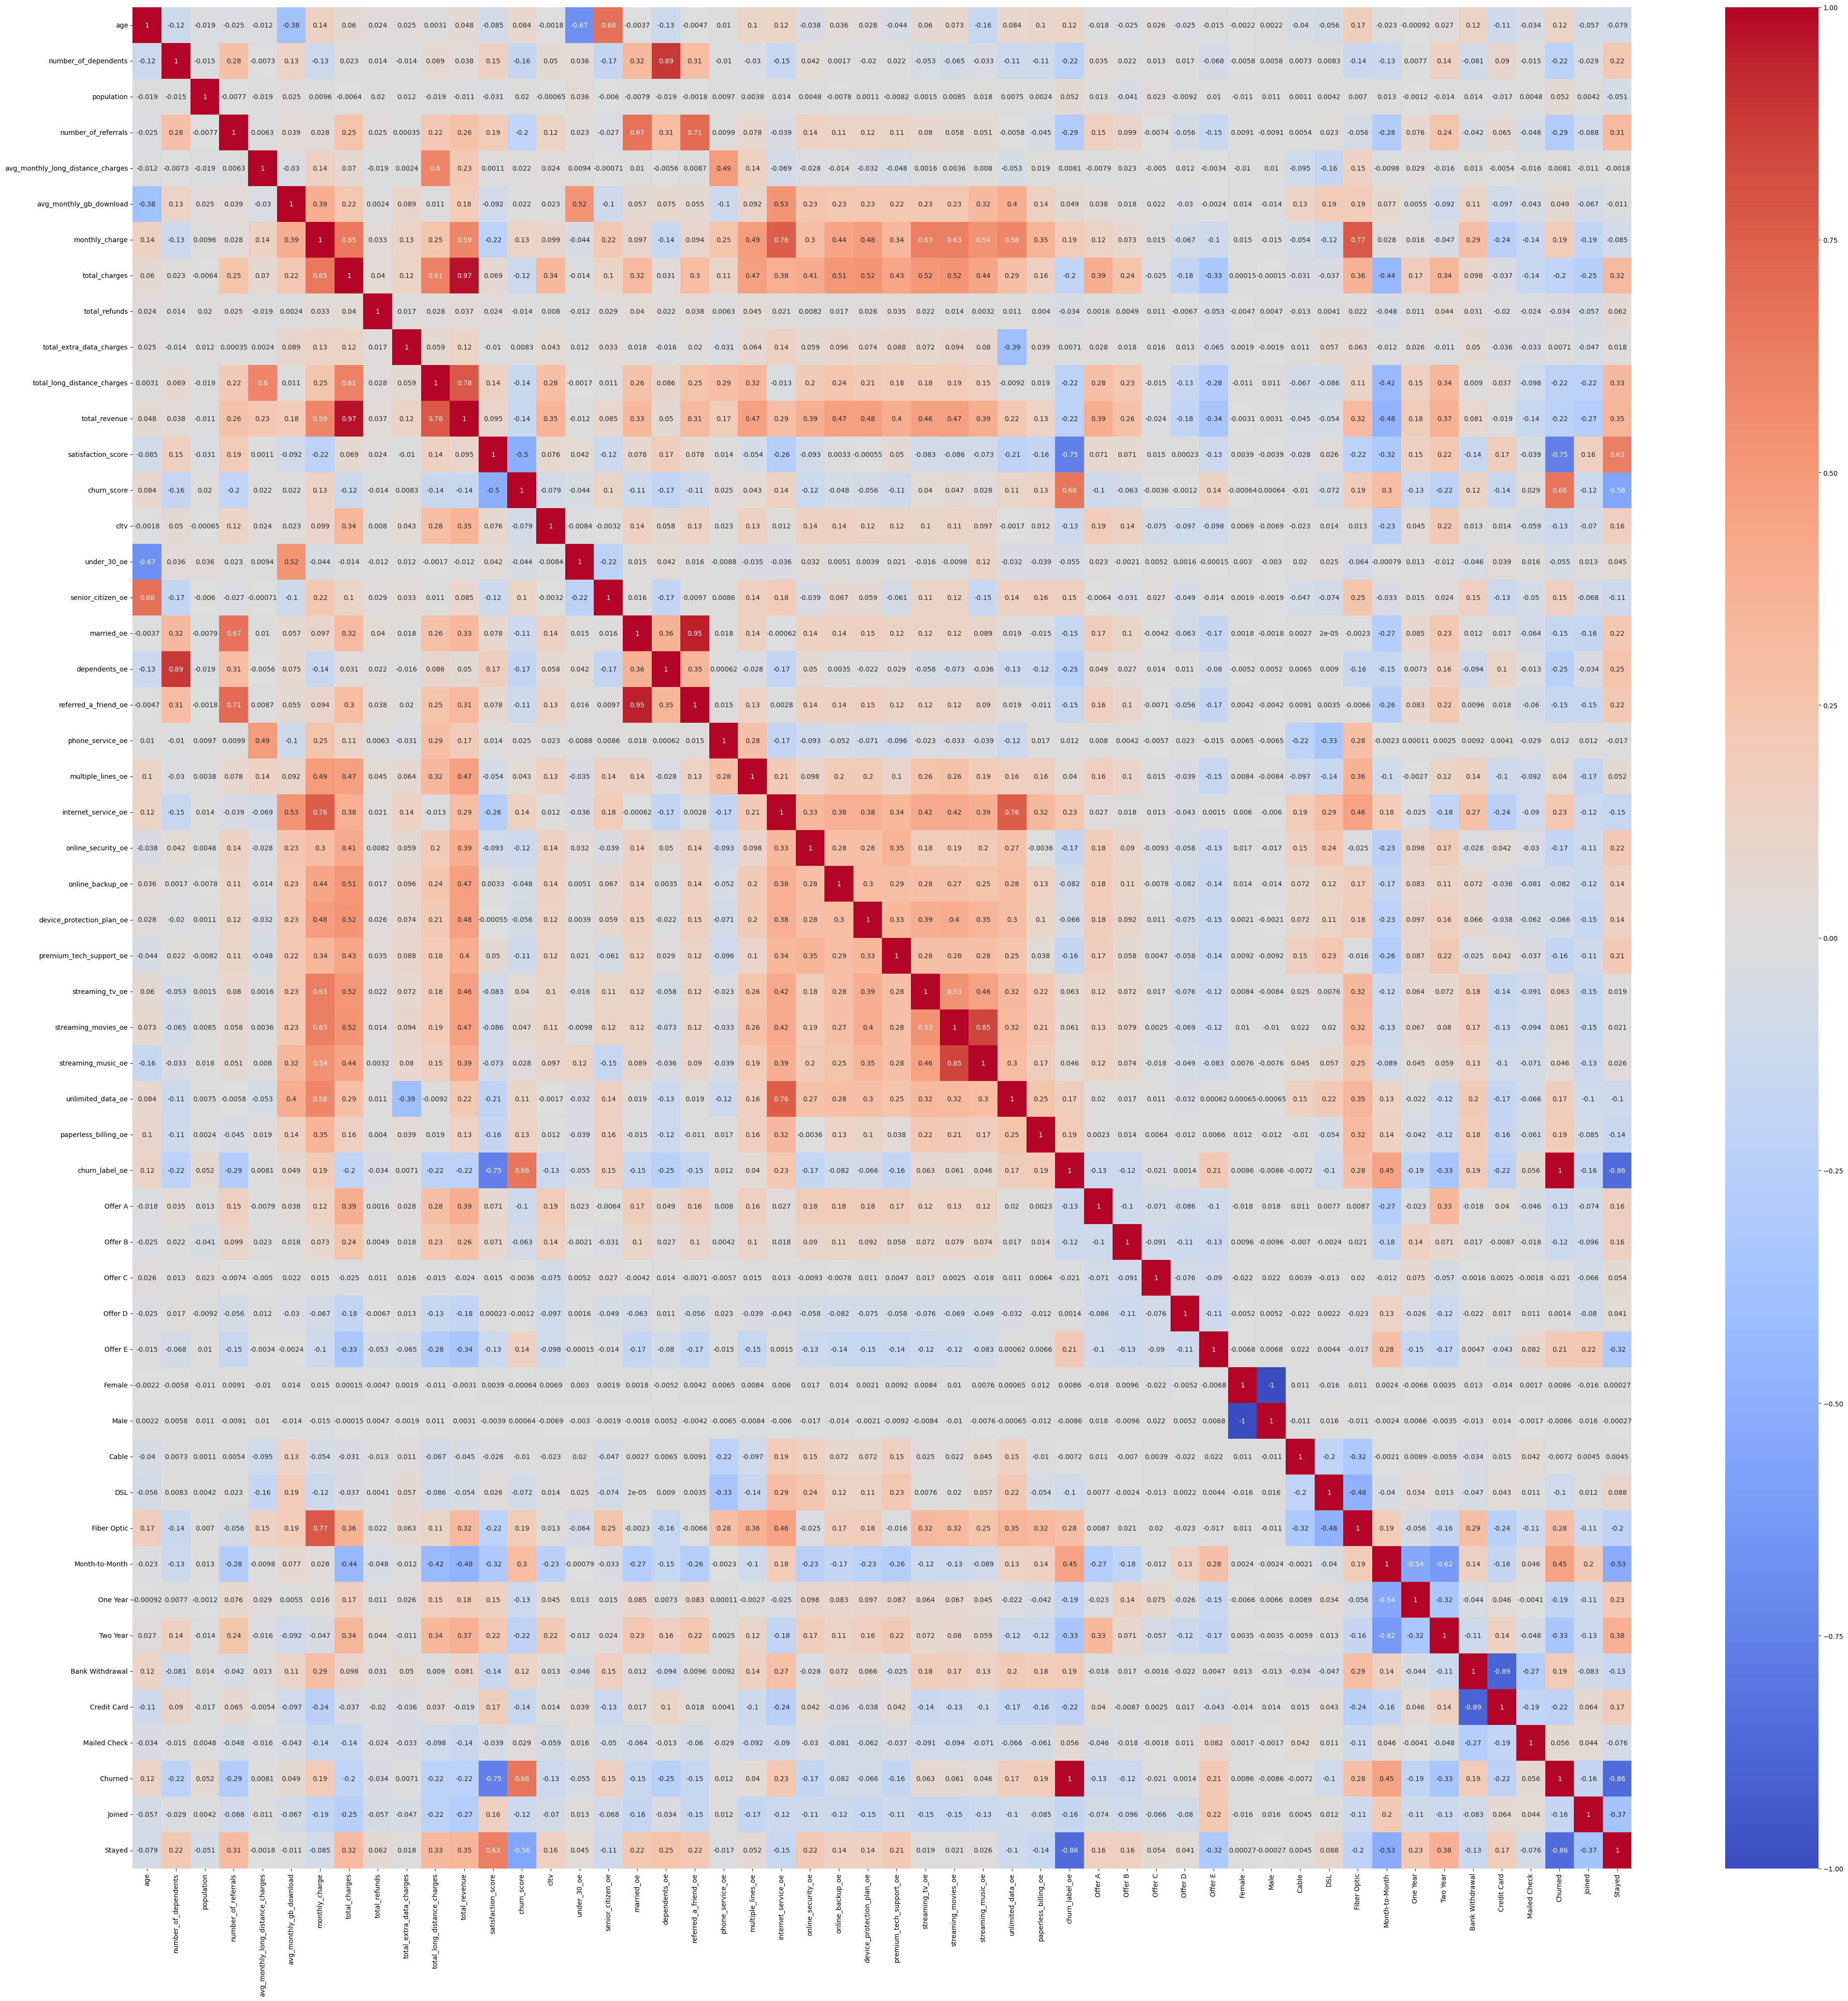

In [23]:
plt.figure(figsize=(50,50))
sns.heatmap(merge_df.corr(), cmap='coolwarm', annot=True)
plt.show()

### Data Exploration

In [24]:
sns.set(style="whitegrid")

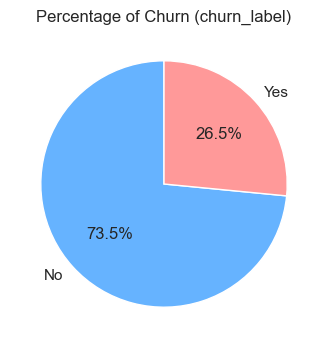

In [25]:
# สัดส่วนคนเลิกใช้บริการ (churn_label)
plt.figure(figsize=(6, 4))
churn_counts = df['churn_label'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Percentage of Churn (churn_label)')
plt.show()

# Insight: คนเลิกใช้สัญญา (Yes) มีน้อยกว่าคนอยู่ต่อ (No)

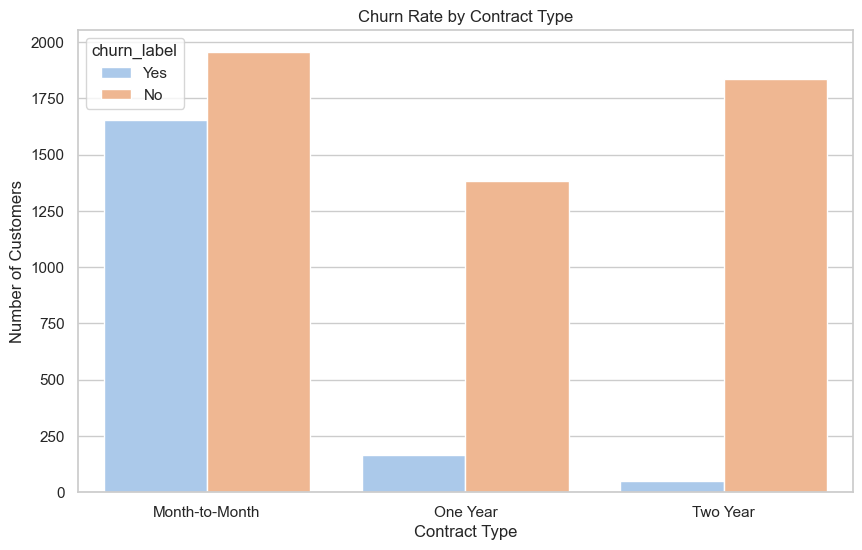

In [26]:
# วิเคราะห์การต่อสัญญา: ประเภทสัญญา กับ การเลิกใช้
plt.figure(figsize=(10, 6))
sns.countplot(x='contract', hue='churn_label', data=df, palette='pastel')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

#Insight: ลูกค้าแบบรายเดือน (Month-to-month) มีอัตราการยกเลิกสูง โดยที่สัญญา 2 ปี (Two year) แทบไม่มีการยกเลิกเลย

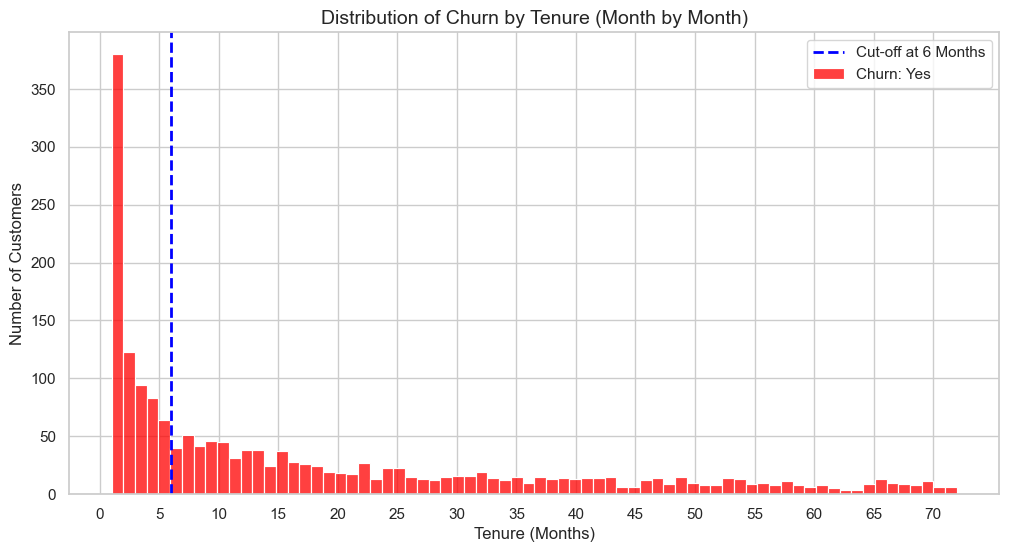

In [27]:
# วิเคราะห์ระยะเวลา: ระยะเวลาเป็นลูกค้า กับ การเลิกใช้
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(df[df['churn_label'] == 'Yes']['tenure_in_months'],
             bins=72, color='red', label='Churn: Yes')

plt.axvline(x=6, color='blue', linestyle='--', linewidth=2, label='Cut-off at 6 Months')

plt.xticks(range(0, 75, 5))

plt.title('Distribution of Churn by Tenure (Month by Month)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

# Insight: Early Churn สูงมากในช่วง 1-6 เดือนแรก ลูกค้าใหม่มีความเสี่ยงที่จะยกเลิกสัญญามากที่สุด

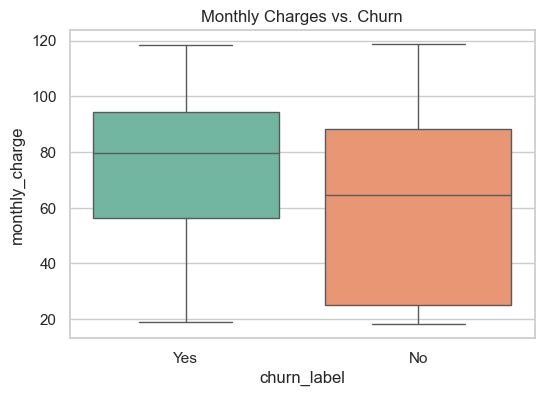

In [28]:
# Monthly Charges vs. Churn (ค่าบริการรายเดือน)
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn_label', y='monthly_charge', data=df, hue='churn_label', legend=False, palette='Set2')
plt.title('Monthly Charges vs. Churn')
plt.show()

# Insight: ลูกค้าที่ ยกเลิกสัญญา มียอดชำระรายเดือนเฉลี่ย สูงกว่า กลุ่มที่อยู่ต่อ

### Data Modeling

In [29]:
merge_df

,age,number_of_dependents,population,number_of_referrals,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,...,Fiber Optic,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check,Churned,Joined,Stayed
0,78,0,68701,0,0.00,8,39.65,39.65,0.00,20,...,0,1,0,0,1,0,0,1,0,0
1,74,1,55668,1,48.85,17,80.65,633.30,0.00,0,...,1,1,0,0,0,1,0,1,0,0
2,71,3,47534,0,11.33,52,95.45,1752.55,45.61,0,...,1,1,0,0,1,0,0,1,0,0
3,78,1,27778,1,19.76,12,98.50,2514.50,13.43,0,...,1,1,0,0,1,0,0,1,0,0
4,80,1,26265,1,6.33,14,76.50,2868.15,0.00,0,...,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,30,0,2182,0,22.77,0,21.15,1419.40,19.31,0,...,0,0,0,1,1,0,0,0,0,1
7039,38,2,18980,1,36.05,24,84.80,1990.50,48.23,0,...,0,0,1,0,0,0,1,0,0,1
7040,30,2,42,4,29.66,59,103.20,7362.90,45.38,0,...,1,0,1,0,0,1,0,0,0,1
7041,32,2,301,1,0.00,17,29.60,346.45,27.24,0,...,0,1,0,0,1,0,0,0,0,1


<Axes: xlabel='churn_label_oe', ylabel='churn_score'>

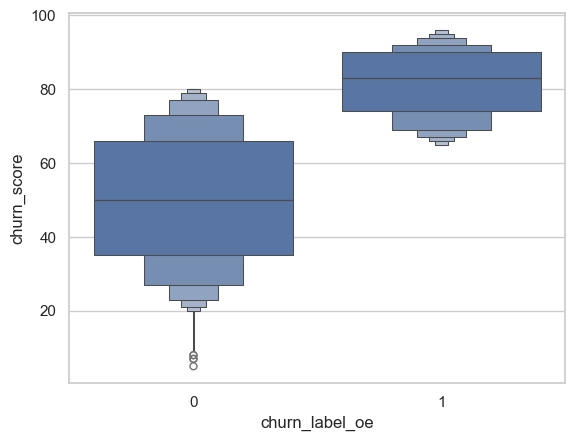

In [30]:
sns.boxenplot(x='churn_label_oe',y='churn_score',data=merge_df)

<p>ลดoverfit

In [31]:
no_churn_df = merge_df.drop(columns=['churn_score','Churned','Stayed'])

In [32]:
no_churn_df.columns

Index(['age', 'number_of_dependents', 'population', 'number_of_referrals',
       'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
       'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'satisfaction_score', 'cltv', 'under_30_oe',
       'senior_citizen_oe', 'married_oe', 'dependents_oe',
       'referred_a_friend_oe', 'phone_service_oe', 'multiple_lines_oe',
       'internet_service_oe', 'online_security_oe', 'online_backup_oe',
       'device_protection_plan_oe', 'premium_tech_support_oe',
       'streaming_tv_oe', 'streaming_movies_oe', 'streaming_music_oe',
       'unlimited_data_oe', 'paperless_billing_oe', 'churn_label_oe',
       'Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E', 'Female', 'Male',
       'Cable', 'DSL', 'Fiber Optic', 'Month-to-Month', 'One Year', 'Two Year',
       'Bank Withdrawal', 'Credit Card', 'Mailed Check', 'Joined'],
      dtype='object')

<p>train-test

In [33]:
target = 'churn_label_oe'

In [34]:
x = no_churn_df.drop(columns=target)
x.columns

Index(['age', 'number_of_dependents', 'population', 'number_of_referrals',
       'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
       'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'satisfaction_score', 'cltv', 'under_30_oe',
       'senior_citizen_oe', 'married_oe', 'dependents_oe',
       'referred_a_friend_oe', 'phone_service_oe', 'multiple_lines_oe',
       'internet_service_oe', 'online_security_oe', 'online_backup_oe',
       'device_protection_plan_oe', 'premium_tech_support_oe',
       'streaming_tv_oe', 'streaming_movies_oe', 'streaming_music_oe',
       'unlimited_data_oe', 'paperless_billing_oe', 'Offer A', 'Offer B',
       'Offer C', 'Offer D', 'Offer E', 'Female', 'Male', 'Cable', 'DSL',
       'Fiber Optic', 'Month-to-Month', 'One Year', 'Two Year',
       'Bank Withdrawal', 'Credit Card', 'Mailed Check', 'Joined'],
      dtype='object')

In [35]:
y = no_churn_df[target]
y

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: churn_label_oe, Length: 7043, dtype: int64

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

<p>train and test data

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

<p>create model

In [38]:
model = RandomForestClassifier()

<p>train model

In [39]:
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<p>prediction

In [40]:
y_pred = model.predict(x_test)

<p>evaluate model

In [41]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [42]:
accuracy = accuracy_score(y_test,y_pred)
print("accuracy: ",accuracy)

accuracy:  0.9616658778987222


In [43]:
report = classification_report(y_test,y_pred)
print("classification report\n\n",report)

classification report

               precision    recall  f1-score   support

           0       0.95      1.00      0.97      1524
           1       0.99      0.87      0.93       589

    accuracy                           0.96      2113
   macro avg       0.97      0.93      0.95      2113
weighted avg       0.96      0.96      0.96      2113



In [44]:
matrix = confusion_matrix(y_test,y_pred)
print("confusion matrix\n\n",matrix)

confusion matrix

 [[1518    6]
 [  75  514]]


### Data Deployment